# 🌍 Análise de Desenvolvimento Humano (IDHM 2010)
# Pergunta Norteadora: "Quais são os Estados que possuem um bom IDH para que possamos entregar bons produtos?"

# ==============================================================================
# 1. SETUP E BIBLIOTECAS (Rigor de MLOps e Documentação)
# ==============================================================================

In [1]:
import os           # Gestão de arquivos e pastas no sistema operacional
import sys          # Parâmetros e funções específicas do sistema
from pathlib import Path # Manipulação moderna de caminhos de arquivos (POO)

import pandas as pd  # Ferramenta principal para análise e manipulação de DataFrames
import numpy as np   # Operações matemáticas e computação numérica eficiente

import matplotlib.pyplot as plt # Base para geração de gráficos estáticos
import seaborn as sns           # Interface de alto nível para gráficos estatísticos
import plotly.express as px     # Visualizações interativas (ideal para mapas)

import warnings                 # Controle de notificações e alertas
warnings.filterwarnings('ignore') # Silencia avisos para manter o output limpo

# Configurações de Rigor Visual
plt.style.use('ggplot')
sns.set_theme(style="whitegrid", palette="viridis")
pd.set_option('display.max_columns', None)        
pd.set_option('display.float_format', '{:.4f}'.format) 

print("🚀 Ambiente configurado para análise estratégica de IDHM!")


🚀 Ambiente configurado para análise estratégica de IDHM!


# ==============================================================================
# 2. CARGA DOS DADOS (Data Acquisition - Aula 2.1)
# ==============================================================================

In [2]:
path_file = "../../Base de dados IDH/IDH_2010.xls"

try:
    idhm = pd.read_excel(path_file, engine='xlrd')
    print(f"✅ Sucesso! Arquivo carregado: {path_file}")
except Exception as e:
    print(f"❌ Erro crítico na carga: {e}")

✅ Sucesso! Arquivo carregado: ../../Base de dados IDH/IDH_2010.xls


# ==============================================================================
# 3. DATA CLEANING E TRANSFORMAÇÃO (Preparação da Base)
# ==============================================================================
# Seleção das colunas estratégicas

In [3]:
df_idhm = idhm[[
    'Nome da Unidade da Federação', 
    'Município', 
    'IDHM', 
    'IDHM Educação', 
    'IDHM Longevidade', 
    'IDHM Renda'
]].copy()

# Renomeação para snake_case (Removendo acentos e espaços)

In [4]:
df_idhm.columns = [
    'nome_da_unidade_da_federacao', 
    'municipio', 
    'idhm', 
    'idhm_educacao', 
    'idhm_longevidade', 
    'idhm_renda'
]

# ==============================================================================
# 4. IMPORTÂNCIA DA ESTATÍSTICA DESCRITIVA (Aula 2.2)
# ==============================================================================
# Aqui aplicamos o rigor matemático para entender a dispersão e tendência central

In [5]:
print("\n📊 ESTATÍSTICA DESCRITIVA DA BASE NACIONAL:")
display(df_idhm.describe())

# Insight estatístico: Verificando a assimetria (Skewness) do IDHM
media = df_idhm['idhm'].mean()
mediana = df_idhm['idhm'].median()
print(f"\n💡 Análise de Tendência Central:")
print(f"- Média Nacional: {media:.4f}")
print(f"- Mediana Nacional: {mediana:.4f}")
if media < mediana:
    print("- Resultado: Assimetria Negativa (A maioria dos municípios está acima da média).")


📊 ESTATÍSTICA DESCRITIVA DA BASE NACIONAL:


,idhm,idhm_educacao,idhm_longevidade,idhm_renda
count,5564.0000,5564.0000,5564.0000,5564.0000
mean,0.6592,0.5591,0.8016,0.6429
std,0.0720,0.0933,0.0447,0.0807
min,0.4180,0.2070,0.6720,0.4000
25%,0.5990,0.4900,0.7690,0.5720
50%,0.6650,0.5600,0.8080,0.6540
75%,0.7180,0.6310,0.8360,0.7070
max,0.8620,0.8250,0.8940,0.8910



💡 Análise de Tendência Central:
- Média Nacional: 0.6592
- Mediana Nacional: 0.6650
- Resultado: Assimetria Negativa (A maioria dos municípios está acima da média).


# ==============================================================================
# 5. AGRUPANDO OS DADOS PARA A ANÁLISE (Aula 2.3)
# ==============================================================================
# Agrupando por Estado para identificar os "Mercados Premium"
# Incluímos a contagem de municípios para entender a capilaridade de cada Estado

In [6]:
df_uf = df_idhm.groupby('nome_da_unidade_da_federacao').agg({
    'idhm': ['mean', 'median', 'std'],
    'municipio': 'count'
}).sort_values(by=('idhm', 'mean'), ascending=False)

# Renomeando colunas do multi-index para facilitar o uso
df_uf.columns = ['idhm_medio', 'idhm_mediana', 'idhm_desvio_padrao', 'qtd_municipios']

print("\n🏆 RANKING DE ESTADOS (Visão Consolidada):")
display(df_uf)


🏆 RANKING DE ESTADOS (Visão Consolidada):


,idhm_medio,idhm_mediana,idhm_desvio_padrao,qtd_municipios
nome_da_unidade_da_federacao,,,,
Distrito Federal,0.8240,0.8240,NaN,1
São Paulo,0.7395,0.7380,0.0325,645
Santa Catarina,0.7316,0.7360,0.0402,293
Rio Grande do Sul,0.7135,0.7170,0.0412,496
Rio de Janeiro,0.7089,0.7125,0.0368,92
Paraná,0.7020,0.7060,0.0386,399
Goiás,0.6950,0.6970,0.0335,246
Espírito Santo,0.6922,0.6835,0.0381,78
Mato Grosso,0.6843,0.6860,0.0383,141


# ==============================================================================
# 6. UTILIZANDO GRÁFICOS PARA DETERMINAR INSIGHTS (Aula 2.4)
# ==============================================================================
# 6.1. Visualização do Ranking de Mercado

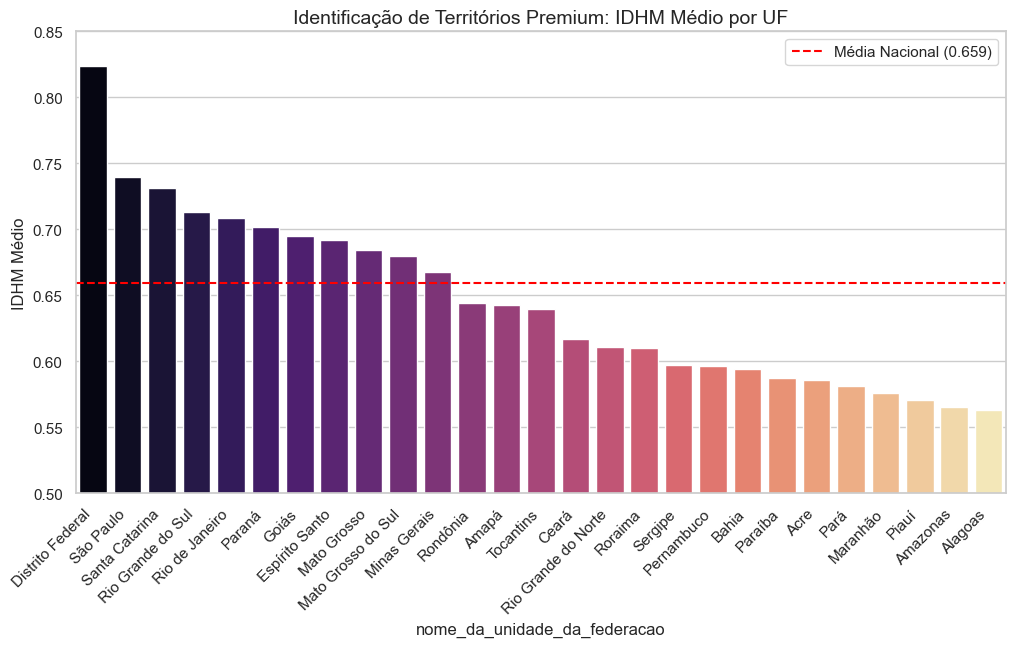

In [7]:
plt.figure(figsize=(12, 6))
sns.barplot(x=df_uf.index, y=df_uf['idhm_medio'], palette='magma')

# Linha de referência da Média Nacional
plt.axhline(media, color='red', linestyle='--', label=f'Média Nacional ({media:.3f})')

plt.title('Identificação de Territórios Premium: IDHM Médio por UF', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.ylabel('IDHM Médio')
plt.ylim(0.5, 0.85)
plt.legend()
plt.show()

# 6.2. Análise de Correlação entre as Dimensões (Insight de Produto)
# Para saber se o foco deve ser em renda ou longevidade/estilo de vida

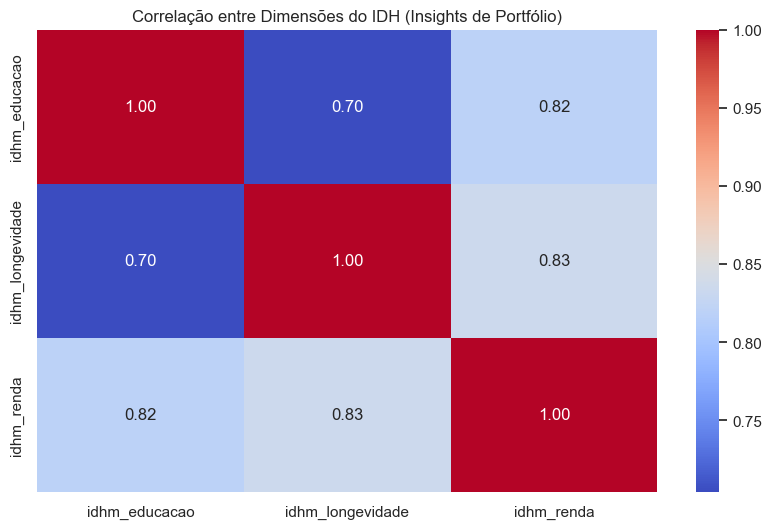

In [8]:
plt.figure(figsize=(10, 6))
correlation_matrix = df_idhm[['idhm_educacao', 'idhm_longevidade', 'idhm_renda']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlação entre Dimensões do IDH (Insights de Portfólio)')
plt.show()

# ==============================================================================
# 7. CONCLUSÃO ESTRATÉGICA
# ==============================================================================

In [9]:
print("\n💡 CONCLUSÃO ESTRATÉGICA PARA O NEGÓCIO:")
top_3 = df_uf.index[:3].tolist()
print(f"1. Foco Geográfico: Os estados {', '.join(top_3)} são os mais promissores.")
print(f"2. Perfil de Consumo: A alta correlação entre IDH Renda e Longevidade sugere")
print("   um público que valoriza produtos de qualidade e durabilidade.")


💡 CONCLUSÃO ESTRATÉGICA PARA O NEGÓCIO:
1. Foco Geográfico: Os estados Distrito Federal, São Paulo, Santa Catarina são os mais promissores.
2. Perfil de Consumo: A alta correlação entre IDH Renda e Longevidade sugere
   um público que valoriza produtos de qualidade e durabilidade.


# ==============================================================================
# 8. TESTES UNITÁRIOS (Rigor de Engenharia & MLOps)
# ==============================================================================
# Implementamos funções de teste para garantir a integridade do pipeline de dados.

In [10]:
def test_data_pipeline():
    """Suite de testes para validar limpeza, tipos e integridade geográfica."""
    print("\n🧪 Executando Auditoria Automática de Dados...")
    
    # Teste 1: Validação de Renomeação (Snake Case)
    assert 'nome_da_unidade_da_federacao' in df_idhm.columns, "❌ Erro: Coluna UF não localizada."
    
    # Teste 2: Validação de Qualidade (Nulos)
    assert df_idhm['idhm'].isnull().sum() == 0, "❌ Erro: Detectados valores nulos no indicador IDHM."
    
    # Teste 3: Consistência Geográfica (Brasil possui 27 UFs)
    assert len(df_uf) == 27, f"❌ Erro Geográfico: Esperado 27 UFs, encontrado {len(df_uf)}."
    
    # Teste 4: Validação de Escala (IDH deve estar entre 0 e 1)
    assert df_idhm['idhm'].max() <= 1.0 and df_idhm['idhm'].min() >= 0, "❌ Erro: Escala de IDHM inválida."

    print("✅ Sucesso: O pipeline de dados passou em todos os testes de integridade!")

# Rodar os testes diretamente no Notebook
try:
    test_data_pipeline()
except AssertionError as e:
    print(e)


🧪 Executando Auditoria Automática de Dados...
✅ Sucesso: O pipeline de dados passou em todos os testes de integridade!
